# makemore: part 5 (building a WaveNet)


## Overview
Base architecture <br/>

<img src="./assets/mlp-architecture.png" style="max-width: 600px">


- increase context length
- Input single layer: Squash information too quick
  - Solution: Implement wavenet
  

Wavenet architecture <br/>

<img src="./assets/wavenet-architecture.png" style="max-width: 600px">
### Refs
- [wavenet](https://arxiv.org/abs/1609.03499)
- [DeepMind blog post from 2016](https://www.deepmind.com/blog/wavenet-a-generative-model-for-raw-audio)


---
## Enhancement Roadmap

In [196]:
## This is section just for demonstrate how dimension change thorugh torch meethods

print(torch.arange(10, dtype=torch.float64).view(-1, 2))
# mean over row (mean over elemnts horizontally), collapses columns (process each elemnt column by column)
print(torch.arange(10, dtype=torch.float64).view(-1, 2).mean(1, keepdim = True))
# sum over row (sum over elemnts horizontally), collapses columns
print(torch.arange(10, dtype=torch.float64).view(-1, 2).sum(1, keepdim = True))

tensor([[0., 1.],
        [2., 3.],
        [4., 5.],
        [6., 7.],
        [8., 9.]], dtype=torch.float64)
tensor([[0.5000],
        [2.5000],
        [4.5000],
        [6.5000],
        [8.5000]], dtype=torch.float64)
tensor([[ 1.],
        [ 5.],
        [ 9.],
        [13.],
        [17.]], dtype=torch.float64)


### Dimensions Check (Flatten method enhancement)
Original dimensions <br/>
context_size: 8 (At this point, we have change from 3 to 8)
emb_dim = 10
number of neurons in hidden layer: 200

Wavenet dimensions <br/>
context_size: 8 
emb_dim = 10
number of neurons in hidden layer: 200
In first layer, we want each context sample (len = 8) be condensed into 4 bigrams. 4 len-2 samples. Each sample should be represetned by 20 dimensioanl vector


In [197]:
## Original Dimensions
ix = torch.randint(0, Xtr.shape[0], (4, ))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)

print(model.layers[0].out.shape) # embedding layer. 4 examples, context length 8, each char can be represented by 10 dimsional vector
print(model.layers[1].out.shape) # flatten layer. 4 examples, concatenated input (8 * 10)
print(model.layers[2].out.shape) # linear layer before activation. 200: number of neurons it has

# Demonstration
# (torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape -> (4, 200)

torch.Size([4, 8])
torch.Size([4, 8, 10])
torch.Size([4, 4, 20])
torch.Size([4, 4, 68])


In [198]:
## Enhanced Dimensions
# The matrix multiplication works on last dim of the left matrix ()
(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape

torch.Size([4, 4, 200])

In [199]:
# So we want (4, 8, 10) -> (4, 4, 20)
# 2 ways of implementation

## Imp 1
# Get even elems
list(range(10))[::2]
# Get odd elems
list(range(10))[1::2]

vec = torch.randn(4, 8, 10)
explicit_cds = torch.cat([vec[:, ::2, :], vec[:, 1::2, :]], dim = 2)


## Imp 2
implicit_cds = vec.view(4, -1, 20) # same as vec.view(4, 4, 20)

vec.shape, explicit_cds.shape, implicit_cds.shape

# The equation shows that 2 matrices are same
# explicit_cds == implicit_cds

(torch.Size([4, 8, 10]), torch.Size([4, 4, 20]), torch.Size([4, 4, 20]))

---

In [200]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [201]:
# download the names.txt file from github
# !wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

In [202]:
# read in all the words
# words = open('names.txt', 'r').read().splitlines()
words = open('./assets/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [203]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [204]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [205]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [206]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


## New implementations
- [Embedding](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html)
- [Flatten](https://docs.pytorch.org/docs/stable/generated/torch.flatten.html)
  - We implement FlattenConsecutive which is not the same as Faltten 
- [Sequential](https://docs.pytorch.org/docs/stable/nn.html#containers)
- [batchnorm1d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)

### Batchnorm bug
So in previous batchnorm implementation with wavenet strucutre. Let's dig into first batchnorm layer to see what went wrong. So through the code 

```python
for l in model.layers:
    print(f"{l.__class__.__name__:<20} : {l.out.shape}")
```
we can see the shape of each layer

```
Embedding            : torch.Size([32, 8, 10])
FlattenConsecutive   : torch.Size([32, 4, 20])
Linear               : torch.Size([32, 4, 68])
BatchNorm1d          : torch.Size([32, 4, 68])
Tanh                 : torch.Size([32, 4, 68])
FlattenConsecutive   : torch.Size([32, 2, 136])
Linear               : torch.Size([32, 2, 68])
BatchNorm1d          : torch.Size([32, 2, 68])
Tanh                 : torch.Size([32, 2, 68])
FlattenConsecutive   : torch.Size([32, 136])
Linear               : torch.Size([32, 68])
BatchNorm1d          : torch.Size([32, 68])
Tanh                 : torch.Size([32, 68])
Linear               : torch.Size([32, 27])
```
We can use the following example to demonstrate what would go wrong in old implementation.

```python
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim = True) # (1, 4, 68)
evar = e.var(0, keepdim = True) # (1, 4, 68)
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # (32, 4, 68)
emean.shape, evar.shape, ehat.shape
```

Both emean and evar have dimension (1, 4, 68) which means we calculate mean and variace in parallel for 4 context groups (at this layer it is bigram). But we acutally want to compute mean and variance for 68 channels. To visualize our goal, we want to compute means and variacne by collapsing layer vertically and horizontally and in the and to get shape (1,1,68).
In mean example, for now we only average 32 numbers, but actucally we want to average over 32 * 4 numbers for every 1 of 64 channels


The wrong implementation still work without error is that when we comput ehat, the pytorch will perform broadcasting to mask the underlining error.

To correct the batchnorm we can see that [torch.mean](https://docs.pytorch.org/docs/stable/generated/torch.mean.html#torch.mean) can accept tupple-dim. And we pass the (0,1) now we get the correct dimension for eman and evar which is (1,1,68)

```python
e = torch.randn(32, 4, 68)
emean = e.mean((0,1), keepdim = True) # (1, 1, 68)
evar = e.var((0, 1), keepdim = True) # (1, 1, 68)
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # (32, 4, 68)
emean.shape, evar.shape, ehat.shape
```

### Batchnorm implementation deviation
At the shape section of pytorch batchnorm1d, we can see that the pytorch assume the shape of input should be either (N, C) or (N,C,L)

- N: is the batch size, 
- C: is the number of features or channels, and
- L: is the sequence length
<br/>
But our implementation is (N,C) or (N,L,C)

In [207]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
    # num_embeddings: vocab_size
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, x):
        self.out = self.weight[x]
        return self.out

    def parameters(self):
        return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
    def __call__(self, x):
        # batch_size, contexnt_len, embedding_dim
        B, T, C = x.shape
        x = x.view(x.shape[0], T // self.n, C * self.n) # we can do  x.view(x.shape[0], -1, C * self.n), but we should use -1 sparcely and cautiously. It is hard to debug
        if x.shape[1] == 1:
            # We can use x.squeeze but more explicit is better
            x = x.squeeze(dim = 1)
        self.out = x
        return self.out

    def parameters(self):
        return []
# -----------------------------------------------------------------------------------------------
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [208]:
torch.manual_seed(42); # seed rng for reproducibility

## Implementation Note
- We switch n_hidden from 200 to 68 so that the params is aroudn 20k. Which is similar to previous sinlge hidden layer implementation. So we can compare performance.

In [217]:
# original network
# n_embd: 10 - > 24
# n_hidden: 200 -> 68 -> 128
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

# Initial template
# C = torch.randn((vocab_size, n_embd))
# layers = [
#     Linear(block_size * n_embd, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, vocab_size),
# ]


# This is the demonstration how first layer is flatten
# model = Sequential([
#   Embedding(vocab_size, n_embd),
#   FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size),
# ])

# hierarchical network (wavenet structure)
# n_embd = 24 # the dimensionality of the character embedding vectors
# n_hidden = 128 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
    # Scale down weights of output layer so the model wont be confidently wrong.
    layers[-1].weight *= 0.1
  # model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
# Original Template
# parameters = [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True


76579


In [212]:
# Exame shape layer by layer with 4 examples

# ix = torch.randint(0, Xtr.shape[0], (32, ))
# Xb, Yb = Xtr[ix], Ytr[ix]
# logits = model(Xb)

# for layer in model.layers:
#     print(f"{layer.__class__.__name__:<20} : {layer.out.shape}")

Embedding            : torch.Size([32, 8, 10])
FlattenConsecutive   : torch.Size([32, 4, 20])
Linear               : torch.Size([32, 4, 68])
BatchNorm1d          : torch.Size([32, 4, 68])
Tanh                 : torch.Size([32, 4, 68])
FlattenConsecutive   : torch.Size([32, 2, 136])
Linear               : torch.Size([32, 2, 68])
BatchNorm1d          : torch.Size([32, 2, 68])
Tanh                 : torch.Size([32, 2, 68])
FlattenConsecutive   : torch.Size([32, 136])
Linear               : torch.Size([32, 68])
BatchNorm1d          : torch.Size([32, 68])
Tanh                 : torch.Size([32, 68])
Linear               : torch.Size([32, 27])


In [218]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  # logits = model(Xb)

  # Simplify step 1
  # emb = C[Xb]
  # x = emb.view(emb.shape[0], -1)

  # Simplify step 2   
  # x = Xb
  # for l in layers:
    # At the end you will get logits
    # x = l(x)
  
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3038
  10000/ 200000: 2.2001
  20000/ 200000: 2.0702
  30000/ 200000: 1.9769
  40000/ 200000: 1.9745
  50000/ 200000: 1.8075
  60000/ 200000: 2.4187
  70000/ 200000: 1.7440
  80000/ 200000: 2.0037
  90000/ 200000: 1.9272
 100000/ 200000: 1.8153
 110000/ 200000: 1.8434
 120000/ 200000: 1.7604
 130000/ 200000: 1.8838
 140000/ 200000: 2.2748
 150000/ 200000: 2.2985
 160000/ 200000: 1.7322
 170000/ 200000: 1.5948
 180000/ 200000: 1.9727
 190000/ 200000: 1.9547


In [213]:
for l in model.layers:
    print(f"{l.__class__.__name__:<20} : {l.out.shape}")

Embedding            : torch.Size([32, 8, 10])
FlattenConsecutive   : torch.Size([32, 4, 20])
Linear               : torch.Size([32, 4, 68])
BatchNorm1d          : torch.Size([32, 4, 68])
Tanh                 : torch.Size([32, 4, 68])
FlattenConsecutive   : torch.Size([32, 2, 136])
Linear               : torch.Size([32, 2, 68])
BatchNorm1d          : torch.Size([32, 2, 68])
Tanh                 : torch.Size([32, 2, 68])
FlattenConsecutive   : torch.Size([32, 136])
Linear               : torch.Size([32, 68])
BatchNorm1d          : torch.Size([32, 68])
Tanh                 : torch.Size([32, 68])
Linear               : torch.Size([32, 27])


In [185]:
# plt.plot(lossi)
# Since the batch size is 32, the loss is unpredictable becasue 32 is jusr a samll portion of the whole training data set.

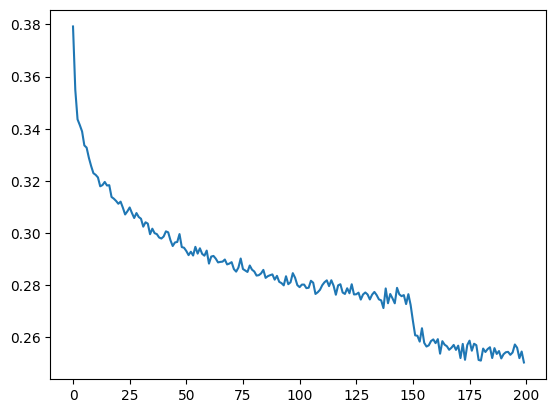

In [219]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
# We can see that around 150k, the loss drop drastically because of learning_rate decay

In [220]:
# Origianl template
# for layer in layers:

# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [221]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]

  # Original template 
  # emb = C[x]
  # x = emb.view(emb.shape[0], -1)
  # for l in layers:
  #   x = l(x)

  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7705419063568115
val 1.987931251525879


## Performance log
Some train, val I just copy and paste it from the Karpathy's note, since I use corrected Batchnorm all the time. I am lazy to re-run the whole process. Maybe in future, I can verify the enchancement performacne again.
### Original
- Hyperparams and settings
    - contexnt length: 3
    - hidden neurson: 200
    - params: 12097 (12k)
    - n_embd = 10
    - n_hidden = 200
- Loss log (copy and paste)
    - train 2.058
    - val 2.105


### Increase context length
context: 3 -> 8
- Hyperparams and settings
    - contexnt length: 8
    - (22K params)
    - flat layer
    - n_embd = 10
    - n_hidden = 200
- Loss log (copy and paste)
    - train 1.918
    - val 2.027

### Hierarchical structure (wavenet)
- Hyperparams and settings
    - contexnt length: 8
    - (22K params)
    - wavenet layers
    - n_embd = 10
    - n_hidden = 68
- Loss log (copy and paste)
    - train 1.941
    - val 2.029

### Correct batchnorm
- Hyperparams and settings
    - Contexnt length: 8
    - (22K params)
    - Wavenet layers
    - Correct batchnorm
    - n_embd = 10
    - n_hidden = 68
- Loss log (My log)
    - train: 1.912
    - val: 2.022 

### Scale up
- Hyperparams and settings
    - Contexnt length: 8
    - (76K params)
    - Wavenet layers
    - Correct batchnorm
    - n_embd = 24
    - n_hidden = 128
- Loss log (My log)
    - train 1.7705419063568115
    - val 1.987931251525879



In [222]:
# sample from the model
for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      # Original template 
      # emb = C[torch.tensor([context])] # emb cahrs into vectors
      # x = emb.view(emb.shape[0], -1) # concatenate the vectors
      # for l in layers:
      #   x = l(x)
      # logits = x
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

raidence.
jestinevie.
elightio.
henesn.
calli.
anyley.
hamidie.
dion.
indil.
zaylen.
gaby.
vycis.
tanshiela.
kashaen.
itzai.
nicole.
fruelis.
izabellah.
annalizae.
aleighann.


### Next time:
Why convolutions? Brief preview/
https://youtu.be/t3YJ5hKiMQ0?t=3025

The convolution has better performance.
- The forward pass in the for-loop can be processed in parallel in CUDA.
- Some activations can be reused without getting computed redundantly.

In [ ]:
for x,y in zip(Xtr[7:15], Ytr[7:15]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .


In [ ]:
# forward a single example:
logits = model(Xtr[[7]])
logits.shape

torch.Size([1, 27])

In [ ]:
# forward all of them
logits = torch.zeros(8, 27)
for i in range(8):
  logits[i] = model(Xtr[[7+i]])
logits.shape

torch.Size([8, 27])

In [ ]:
# convolution is a "for loop"
# allows us to forward Linear layers efficiently over space

## My note on CNN
### [Why vanilla convolution is bad](https://chatgpt.com/s/t_699e9d1b69148191a25e2aa8d8a75748)
In the vanilla convolution, to make a unit in hidden layer to have large enough recptive field to capture global context we need deep number of layers to achieve that. The recptive field size (size * size) grows linearly based on the index of layer

$$
RFS(l) = l(k - 1) + k
$$
- l: index of the layer
- k: kernel size

- recptive field: area that a unit of current layer depends on (the area in previous it can see)
- global context: whole image in the input layer

### [How Pooling help](https://chatgpt.com/s/t_699ea319d06881918650cd4929ac3c6f)
Pooling Makes each pixel represent a larger area in the original image


### [How Dialted convolution help](https://chatgpt.com/s/t_699ea4def3f081918522345fa0dffe8e)
Dilated convolution increases the effective receptive field by inserting gaps between kernel elements, allowing each unit to cover a larger spatial region without increasing parameters or reducing resolution. However, because the sampling is sparse, some intermediate pixels are not directly aggregated at that layer, which can lead to gridding artifacts (some pixels may not interact until much deeper layers.) if not designed carefully.

### Refs
- [Dilated Convolutions and Kronecker Factored Convolutions](https://www.inference.vc/dilated-convolutions-and-kronecker-factorisation/)
